In [4]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

import textwrap

from tqdm import tqdm

In [5]:
# set axis label font size
plt.rc('axes', labelsize=12)

In [6]:
data = pd.read_csv("../output/2-firm/policy_data.csv")
data

,ModelEnvironment_l_max,ModelEnvironment_tau_max,ModelParameters_PROB,ModelParameters_alpha,ModelParameters_beta,ModelParameters_gamma,ModelParameters_n,ModelParameters_sigma,ModelSettings_INNOV_TYPE,ModelSettings_clamp_rate_update,...,d51,d52,d53,d54,d55,d56,d57,d58,d59,d60
0,0.3,60,SQRT,5.0,0.96,1.02,2,1.3,NonChanging,0.05,...,0.000009,0.000009,0.000009,0.000008,0.000008,0.000008,0.000007,0.000007,0.000007,NaN
1,0.3,60,SQRT,5.0,0.96,1.02,2,1.2,NonChanging,0.05,...,0.000025,0.000024,0.000023,0.000023,0.000022,0.000021,0.000020,0.000020,0.000019,NaN
2,0.3,60,SQRT,5.0,0.96,1.02,2,1.4,NonChanging,0.05,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,NaN
3,0.3,60,SQRT,5.0,0.96,1.01,2,1.3,NonChanging,0.05,...,0.000006,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,NaN
4,0.3,60,SQRT,5.0,0.96,1.03,2,1.3,NonChanging,0.05,...,0.000007,0.000006,0.000006,0.000005,0.000005,0.000005,0.000004,0.000004,0.000004,NaN
5,0.3,60,SQRT,5.0,0.94,1.02,2,1.3,NonChanging,0.05,...,0.000009,0.000009,0.000008,0.000008,0.000008,0.000007,0.000007,0.000007,0.000007,NaN
6,0.3,60,SQRT,5.0,0.98,1.02,2,1.3,NonChanging,0.05,...,0.000010,0.000010,0.000009,0.000009,0.000009,0.000008,0.000008,0.000008,0.000008,NaN
7,0.3,60,SQRT,1.0,0.96,1.02,2,1.3,NonChanging,0.05,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000001,0.000001,0.000001,NaN
8,0.3,60,SQRT,10.0,0.96,1.02,2,1.3,NonChanging,0.05,...,0.000019,0.000018,0.000018,0.000017,0.000016,0.000016,0.000015,0.000015,0.000015,NaN


In [7]:
def map_setting_string(df, drop_col):
    setting_cols = [col for col in df.columns if col != drop_col and not col.startswith("d")]
    setting_string = []
    if "ModelParameters_n" in setting_cols:
        val = df['ModelParameters_n'].iloc[0]
        setting_string.append(f"$n$={val}")
    if "ModelParameters_sigma" in setting_cols:
        val = df['ModelParameters_sigma'].iloc[0]
        setting_string.append(f"$\\sigma$={val}")
    if "ModelParameters_beta" in setting_cols:
        val = df['ModelParameters_beta'].iloc[0]
        setting_string.append(f"$\\beta$={val}")
    if "ModelParameters_gamma" in setting_cols:
        val = df['ModelParameters_gamma'].iloc[0]
        setting_string.append(f"$\\gamma$={val}")
    if "ModelParameters_alpha" in setting_cols:
        val = df['ModelParameters_alpha'].iloc[0]
        setting_string.append(f"$\\alpha$={val}")
    if "ModelSettings_sdf_relaxer" in setting_cols:
        val = df['ModelSettings_sdf_relaxer'].iloc[0]
        setting_string.append(f"sdf_relaxer:{val}")
    if "ModelEnvironment_l_max" in setting_cols:
        val = df['ModelEnvironment_l_max'].iloc[0]
        setting_string.append(f"$l_{{max}}$={val}")
    if "ModelEnvironment_tau_max" in setting_cols:
        val = df['ModelEnvironment_tau_max'].iloc[0]
        setting_string.append(f"$\\tau_{{max}}$={val}")
    if "ModelParameters_PROB_INNOV" in setting_cols:
        val = df['ModelParameters_PROB_INNOV'].iloc[0]
        setting_string.append(f"PROB:{val}")
    if "ModelSettings_tol_update" in setting_cols:
        val = df['ModelSettings_tol_update'].iloc[0]
        setting_string.append(f"tol:{val:.0e}")
    return ", ".join(setting_string)

In [8]:
def get_policy_vec(idx):
    policy_cols = [col for col in data.columns if col.startswith("d")]
    return data.loc[idx, policy_cols].values


In [9]:
def find_cmp_rows(df, column_name):
    idx_list = [False] * len(df)
    
    setting_cols = [col for col in df.columns if not col.startswith("d") and col != column_name]
    setting_values = []

    for v, count in df[column_name].value_counts().items():
        if count != 1:
            continue
        setting_values = df[df[column_name] == v][setting_cols].values[0]
        break

    for v, count in df[column_name].value_counts().items():
        if count == 1:
            idx_list = [a or b for a, b in zip((df[column_name] == v), idx_list)]
        else:
            # find the column that has the same values for the setting cols
            temp_cond = [True] * len(df)
            for col, setting_value in zip(setting_cols, setting_values):
                temp_cond = [a and b for a, b in zip((df[col] == setting_value), temp_cond)]
            idx_list = [a or b for a, b in zip(temp_cond, idx_list)]
    return df[idx_list].reset_index(drop=True)

In [10]:
def flatten_policy_vec(df):
    setting_cols = [col for col in df.columns if not col.startswith("d")]
    policy_cols = [col for col in df.columns if col.startswith("d")]
    flat_data = []
    for _, row in df.iterrows():
        new_row = {col: row[col] for col in setting_cols}
        for col in policy_cols:
            new_row['policy'] = row[col]
            new_row['diff_state'] = int(col[1:])  # Extract the number from 'd0', 'd1', etc.
            flat_data.append(new_row.copy())
    return pd.DataFrame(flat_data).dropna().reset_index(drop=True)

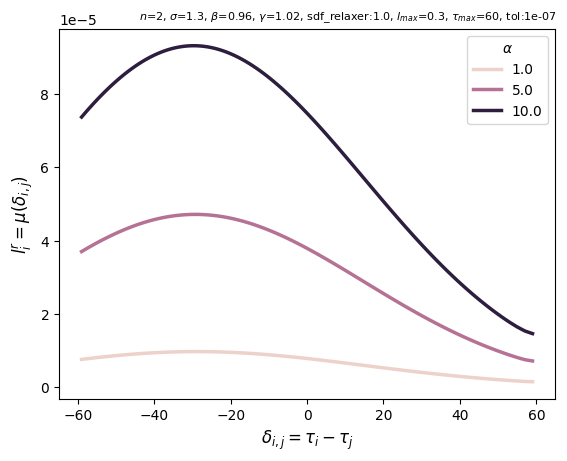

In [11]:
col = 'ModelParameters_alpha'

df = flatten_policy_vec(find_cmp_rows(data, col))
sns.lineplot(data=df, x='diff_state', y='policy', hue=col, linewidth=2.5)
plt.ylabel(r"$l^r_i=\mu(\delta_{i,j})$")
plt.xlabel(r"$\delta_{i,j}= \tau_i - \tau_j$")
plt.legend(title=r"$\alpha$")

setting_str = map_setting_string(find_cmp_rows(data, col), col)
plt.figtext(0.25, 0.9, textwrap.fill(setting_str, width=120), fontsize=8, ha='left')
plt.savefig("../output/2-firm/python_plot/policy_plot_alpha.pdf")

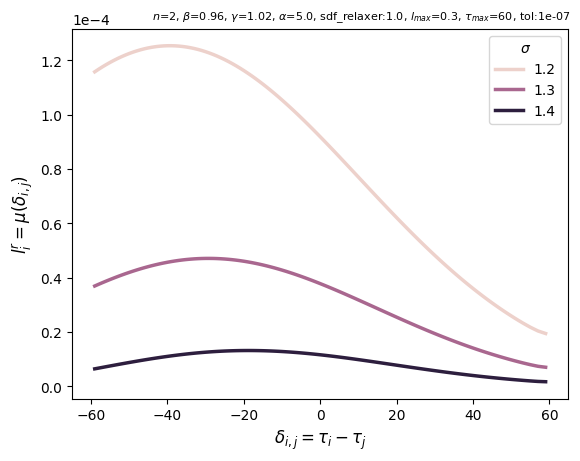

In [12]:
col = 'ModelParameters_sigma'

df = flatten_policy_vec(find_cmp_rows(data, col))
sns.lineplot(data=df, x='diff_state', y='policy', hue=col, linewidth=2.5)
plt.ylabel(r"$l^r_i=\mu(\delta_{i,j})$")
plt.xlabel(r"$\delta_{i,j}= \tau_i - \tau_j$")
plt.legend(title=r"$\sigma$")

setting_str = map_setting_string(find_cmp_rows(data, col), col)
plt.figtext(0.25, 0.9, textwrap.fill(setting_str, width=120), fontsize=8, ha='left')

plt.gca().ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig("../output/2-firm/python_plot/policy_plot_sigma.pdf")

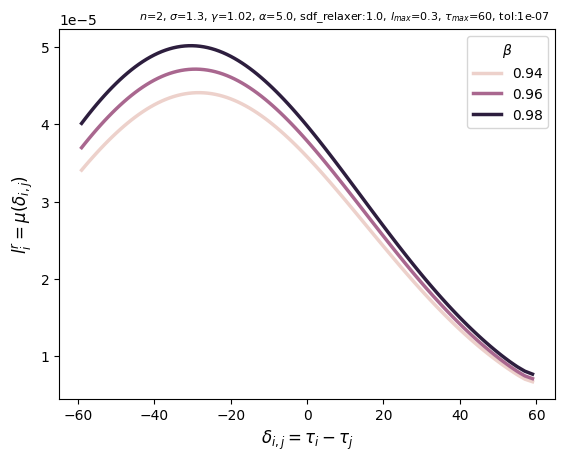

In [13]:
col = 'ModelParameters_beta'

df = flatten_policy_vec(find_cmp_rows(data, col))
sns.lineplot(data=df, x='diff_state', y='policy', hue=col, linewidth=2.5)
plt.ylabel(r"$l^r_i=\mu(\delta_{i,j})$")
plt.xlabel(r"$\delta_{i,j}= \tau_i - \tau_j$")
plt.legend(title=r"$\beta$")

setting_str = map_setting_string(find_cmp_rows(data, col), col)
plt.figtext(0.25, 0.9, textwrap.fill(setting_str, width=120), fontsize=8, ha='left')

plt.gca().ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig("../output/2-firm/python_plot/policy_plot_beta.pdf")

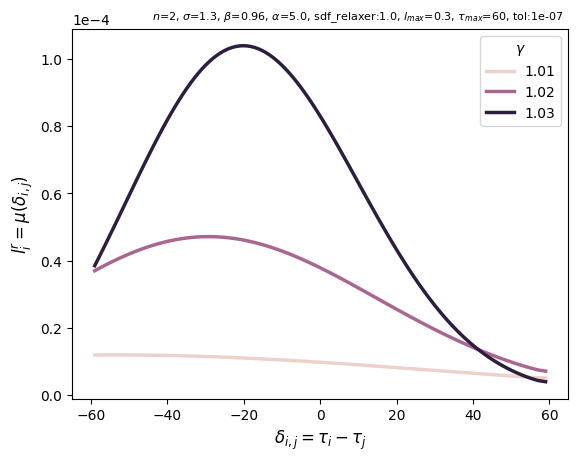

In [14]:
col = 'ModelParameters_gamma'

df = flatten_policy_vec(find_cmp_rows(data, col))
sns.lineplot(data=df, x='diff_state', y='policy', hue=col, linewidth=2.5)
plt.ylabel(r"$l^r_i=\mu(\delta_{i,j})$")
plt.xlabel(r"$\delta_{i,j}= \tau_i - \tau_j$")
plt.legend(title=r"$\gamma$")

setting_str = map_setting_string(find_cmp_rows(data, col), col)
plt.figtext(0.25, 0.9, textwrap.fill(setting_str, width=120), fontsize=8, ha='left')

plt.gca().ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig("../output/2-firm/python_plot/policy_plot_gamma.pdf")

---
# Plot policy and value function

In [15]:
from h5py import File

In [16]:
FILE_PATH = "../output/2-firm/V_P_state_grid.jld2"

with File(FILE_PATH, "r") as f:
    p_grid = f["policy_grid"][:].T
    v_grid = f["V_grid"][:].T

# p_grid, v_grid = p_grid.T, v_grid.T

m = p_grid.shape[0]
tau_grid = np.arange(0, m)

x_axis, y_axis = np.meshgrid(tau_grid, tau_grid)
xd_axis, yd_axis = np.meshgrid(np.arange(-m, m+1), tau_grid)

In [17]:
# convert to difference in technology states
p_grid_diff = np.zeros((m, 2*m + 1)) * np.nan
v_grid_diff = np.zeros((m, 2*m + 1)) * np.nan

v_hat_grid = v_grid / (1.02 ** tau_grid.reshape(-1, 1))
v_hat_grid_diff = np.zeros((m, 2*m + 1)) * np.nan

for i in range(m):
    for j in range(m):
        diff = tau_grid[i] - tau_grid[j]
        p_grid_diff[i, diff + m] = p_grid[i, j]
        v_grid_diff[i, diff + m] = v_grid[i, j]
        v_hat_grid_diff[i, diff + m] = v_hat_grid[i, j]

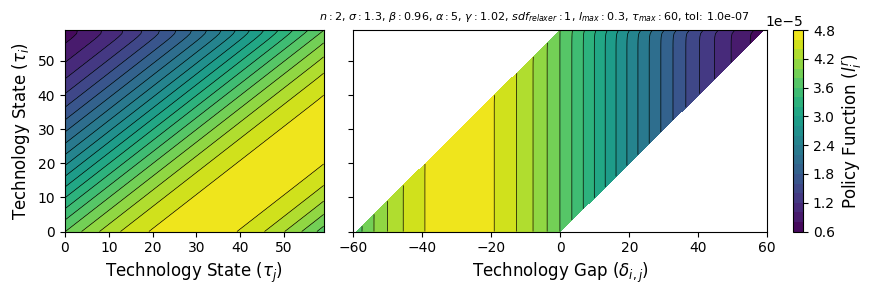

In [18]:
# Plot a contour plot of the policy grid
fig, axs = plt.subplots(
    figsize=(9, 3), ncols=2, nrows=1, 
    sharey=True, gridspec_kw={'width_ratios': [1, 2]}
)

cmap = sns.color_palette("viridis", as_cmap=True)

settings = [
        f"$n: {2}$",
        f"$\\sigma: {1.3}$",
        f"$\\beta: {0.96}$",
        f"$\\alpha: {5}$",
        f"$\\gamma: {1.02}$",
        f"$sdf_{{relaxer}}: {1}$",
        f"$l_{{max}}: {0.3}$",
        f"$\\tau_{{max}}: {60}$",
        f"tol: {1.0e-7:.1e}"
]
setting_str = ", ".join(settings)

ax = axs[0]
ax.contourf(x_axis, y_axis, p_grid, levels=20, cmap=cmap)
ax.contour(x_axis, y_axis, p_grid, levels=20, colors='k', linewidths=0.5)
ax.set_xlabel(r"Technology State ($\tau_j$)")
ax.set_ylabel(r"Technology State ($\tau_i$)")

ax = axs[1]
temp_plot = ax.contourf(xd_axis, yd_axis, p_grid_diff, levels=20, cmap=cmap)
ax.contour(xd_axis, yd_axis, p_grid_diff, levels=20, colors='k', linewidths=0.5)
cbar = fig.colorbar(temp_plot)
cbar.set_label(r"Policy Function ($l^r_i$)")
ax.set_xlabel(r"Technology Gap ($\delta_{i, j}$)")

fig.text(0.36, 0.92, textwrap.fill(setting_str, width=150), fontsize=8, ha='left', va='bottom')
fig.tight_layout()
plt.savefig("../output/2-firm/python_plot/policy_contour_n2.pdf")


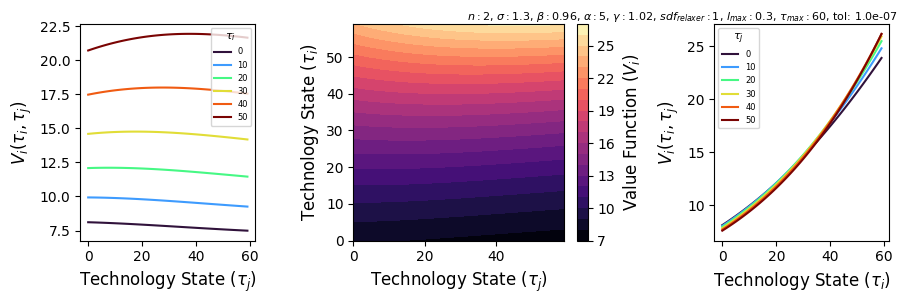

In [19]:
# Plot the value function grid
fig, axs = plt.subplots(
    figsize=(9, 3), ncols=3, nrows=1, 
    gridspec_kw={'width_ratios': [1, 1.5, 1]}
)

cmap = sns.color_palette("magma", as_cmap=True)

settings = [
        f"$n: {2}$",
        f"$\\sigma: {1.3}$",
        f"$\\beta: {0.96}$",
        f"$\\alpha: {5}$",
        f"$\\gamma: {1.02}$",
        f"$sdf_{{relaxer}}: {1}$",
        f"$l_{{max}}: {0.3}$",
        f"$\\tau_{{max}}: {60}$",
        f"tol: {1.0e-7:.1e}"
]
setting_str = ", ".join(settings)


ax = axs[1]
temp_plot = ax.contourf(x_axis, y_axis, v_grid, levels=20, cmap=cmap)
ax.set_xlabel(r"Technology State ($\tau_j$)")
ax.set_ylabel(r"Technology State ($\tau_i$)")
cbar = fig.colorbar(temp_plot)
cbar.set_label(r"Value Function ($V_i$)")


row_list = []
for i in range(0, m, 10):
    for j in range(m):
        row_list.append({
            r"$\tau_i$": (tau_grid[i]),
            r"$\tau_j$": (tau_grid[j]),
            "V": (v_grid[i, j])
        })
df = pd.DataFrame(row_list)

ax = axs[0]
sns.lineplot(data=df, x=r"$\tau_j$", y='V', hue=r"$\tau_i$", palette="turbo", ax=ax)
ax.set_xlabel(r"Technology State ($\tau_j$)")
ax.set_ylabel(r"$V_i(\tau_i, \tau_j)$")
ax.legend(fontsize=6, title=r"$\tau_i$", title_fontsize=8)


row_list = []
for i in range(0, m):
    for j in range(0, m, 10):
        row_list.append({
            r"$\tau_i$": (tau_grid[i]),
            r"$\tau_j$": (tau_grid[j]),
            "V": (v_grid[i, j])
        })
df = pd.DataFrame(row_list)

ax = axs[2]
sns.lineplot(data=df, x=r"$\tau_i$", y='V', hue=r"$\tau_j$", palette="turbo", ax=ax)
ax.set_xlabel(r"Technology State ($\tau_i$)")
ax.set_ylabel(r"$V_i(\tau_i, \tau_j)$")
ax.legend(fontsize=6, title=r"$\tau_j$", title_fontsize=8)

fig.text(0.51, 0.95, textwrap.fill(setting_str, width=150), fontsize=8, ha='left', va='bottom')

fig.tight_layout()
plt.savefig("../output/2-firm/python_plot/value_contour_n2.pdf", bbox_inches='tight')

/Users/2929332h/.julia/conda/3/aarch64/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/2929332h/.julia/conda/3/aarch64/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


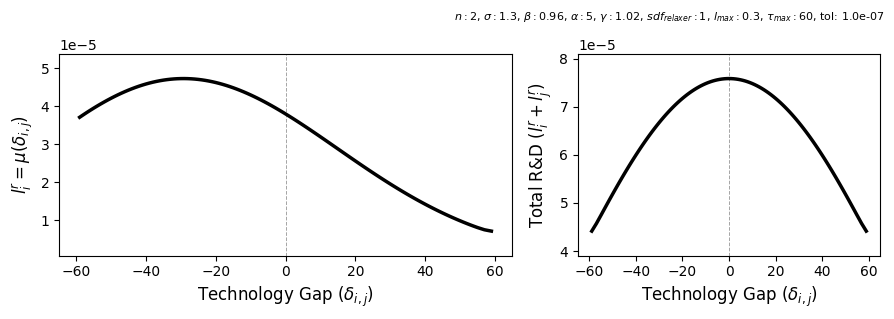

In [20]:
# find the median policy value for each technology gap
median_policy = []
for gap in range(-m, m+1):
    policy_values = p_grid_diff[:, gap + m]
    median_policy.append(np.median(policy_values[~np.isnan(policy_values)]))
median_policy = np.array(median_policy)

fig, axs = plt.subplots(
    figsize=(9, 3), ncols=2, nrows=1,
    gridspec_kw={'width_ratios': [1.5, 1]}
)

ax = axs[0]
ax.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
ax.plot(np.arange(-m, m+1), median_policy, color='black', linewidth=2.5)
ax.set_xlabel(r"Technology Gap ($\delta_{i, j}$)")
ax.set_ylabel(r"$l^r_i = \mu(\delta_{i, j})$")
y_min, y_max = ax.get_ylim()
y_delta = y_max - y_min
ax.set_ylim(y_min - 0.1*y_delta, y_max + 0.1*y_delta)



total_demand = np.zeros_like(median_policy)
for i in range(len(median_policy)):
    l_1 = median_policy[i]
    l_2 = median_policy[len(median_policy) - i-1]
    l_sum = l_1 + l_2

    total_demand[i] = l_sum

ax = axs[1]
ax.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
ax.plot(np.arange(-m, m+1), total_demand, color='black', linewidth=2.5)
ax.set_xlabel(r"Technology Gap ($\delta_{i, j}$)")
ax.set_ylabel(r"Total R&D ($l^r_i + l^r_j$)")
y_min, y_max = ax.get_ylim()
y_delta = y_max - y_min
ax.set_ylim(y_min - 0.1*y_delta, y_max + 0.1*y_delta)

fig.text(0.51, 1.0, textwrap.fill(setting_str, width=150), fontsize=8, ha='left', va='bottom')

fig.tight_layout()
plt.savefig("../output/2-firm/python_plot/policy_total_demand_n2.pdf", bbox_inches='tight')

---
# Find stationary distribution

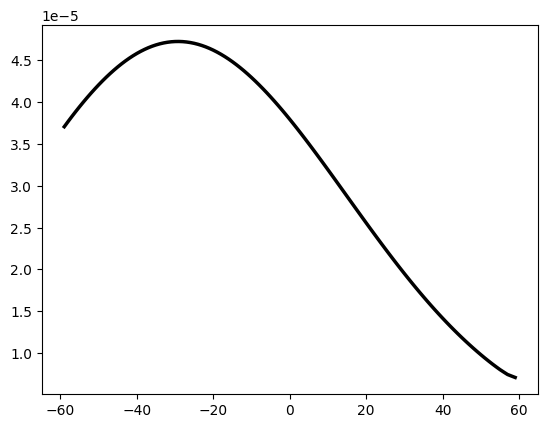

In [21]:
policy_func = median_policy[1:-1] # Remove the nan values at the boundaries
d_states = np.arange(-m+1, m) # Corresponding technology gaps for the policy function
plt.plot(d_states, policy_func, color='black', linewidth=2.5)
plt.show()

In [22]:
def eta(x, alpha = 5.0):
    return np.sqrt(alpha * x)

In [23]:
dim = len(d_states)
P = np.zeros((dim, dim))

for idx, d in enumerate(d_states):
    jdx = -1 * (1 + idx)
    
    l_i = policy_func[idx]
    l_j = policy_func[jdx]

    p_i = eta(l_i)
    p_j = eta(l_j)

    if idx + 1 >= len(policy_func):
        P[idx, idx-1] = (1 - p_i) * p_j
        P[idx, idx] = 1 - P[idx, idx-1]
    elif idx - 1 < 0:
        P[idx, idx + 1] = p_i * (1 - p_j)
        P[idx, idx] = 1 - P[idx, idx + 1]
    else:
        P[idx, idx] = (1 - p_i) * (1 - p_j) + p_i * p_j
        P[idx, idx + 1] = p_i * (1 - p_j)
        P[idx, idx - 1] = (1 - p_i) * p_j

In [74]:
offset = dim // 2
row_list = []

for delta in [-30, 0, 30]:
    idx = delta + offset
    state = np.zeros((dim,1))
    state[idx] = 1.0

    for _ in range(1, 50000):
        new_state = P.T @ state
        if np.allclose(new_state, state, atol=1e-8):
            print(f"Converged for delta={delta}")
            break
        state = new_state
    row_list += [{
        r"$\delta_{i,j}^{(0)}$": delta,
        "x": x,
        "probability": p
    } for x, p in zip(d_states, state.flatten())]


df1 = pd.DataFrame(row_list)

row_list = []

# Add the uniform distribution as a baseline
state = np.ones((dim,1)) / dim
for _ in range(1, 50000):
    new_state = P.T @ state
    if np.allclose(new_state, state, atol=1e-8):
        print("Converged for uniform distribution")
        break
    state = new_state
row_list += [{
        r"$\delta_{i,j}^{(0)}$": "Uniform",
        "x": x,
        "probability": p,
    } for x, p in zip(d_states, state.flatten())]


# Solve for the stationary distribution
eigenvalues, eigenvectors = np.linalg.eig(P.T)
stationary_dist = np.real(eigenvectors[:, np.isclose(eigenvalues, 1)].flatten())
stationary_dist /= stationary_dist.sum()  # Normalize to sum to 1
row_list += [{
        r"$\delta_{i,j}^{(0)}$": "Stationary",
        "x": x,
        "probability": p,
} for x, p in zip(d_states, stationary_dist.flatten())]

df2 = pd.DataFrame(row_list)

Converged for delta=-30
Converged for delta=0
Converged for delta=30
Converged for uniform distribution


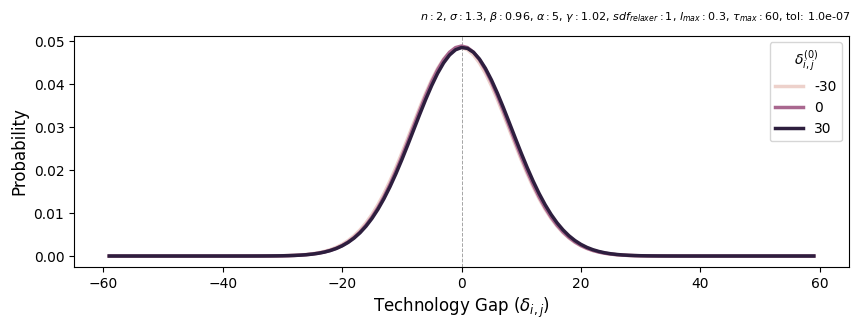

In [75]:
plt.figure(figsize=(10, 3))
plt.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
sns.lineplot(data=df1, x='x', y='probability', hue=r"$\delta_{i,j}^{(0)}$", linewidth=2.5)
plt.xlabel(r"Technology Gap ($\delta_{i, j}$)")
plt.ylabel(r"Probability")
plt.text(-7, 0.055, textwrap.fill(setting_str, width=150), fontsize=8, ha='left')
plt.savefig("../output/2-firm/python_plot/stationary_distribution_n2.pdf", bbox_inches='tight')

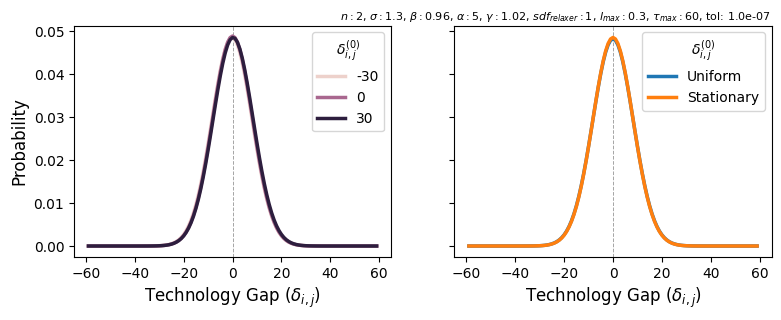

In [76]:
fig, axs = plt.subplots(
    figsize=(9, 3), ncols=2, nrows=1,
    sharey=True, sharex=True, gridspec_kw={'width_ratios': [2, 2]}
)

ax = axs[0]
ax.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
sns.lineplot(data=df1, x='x', y='probability', hue=r"$\delta_{i,j}^{(0)}$", linewidth=2.5, ax=ax)
ax.set_xlabel(r"Technology Gap ($\delta_{i, j}$)")
ax.set_ylabel(r"Probability")


ax = axs[1]
ax.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
sns.lineplot(data=df2, x='x', y='probability', hue=r"$\delta_{i,j}^{(0)}$", linewidth=2.5, ax=ax)
ax.set_xlabel(r"Technology Gap ($\delta_{i, j}$)")
ax.set_ylabel(r"Probability")

fig.text(0.42, 0.9, textwrap.fill(setting_str, width=150), fontsize=8, ha='left')
plt.savefig("../output/2-firm/python_plot/stationary_distribution_full_n2.pdf", bbox_inches='tight')

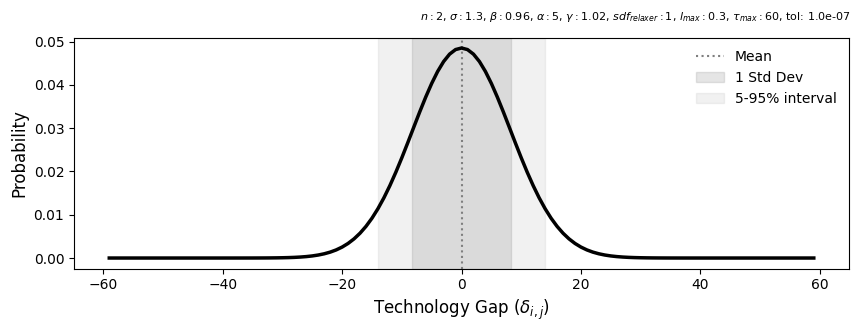

In [98]:
# Plot the stationary distribution with mean and std

eigenvalues, eigenvectors = np.linalg.eig(P.T)
stationary_dist = np.real(eigenvectors[:, np.isclose(eigenvalues, 1)].flatten())
stationary_dist /= stationary_dist.sum()  

stationary_mean = np.sum(d_states * stationary_dist)
stationary_std = np.sqrt(np.sum((d_states - stationary_mean)**2 * stationary_dist))

cdf = np.cumsum(stationary_dist)
q5 = d_states[np.searchsorted(cdf, 0.05)]
q95 = d_states[np.searchsorted(cdf, 0.95)]

plt.figure(figsize=(10, 3))
plt.axvline(stationary_mean, color='tab:gray', linestyle=':', label='Mean')
plt.axvspan(stationary_mean - stationary_std, stationary_mean + stationary_std, color='tab:gray', alpha=0.2, label='1 Std Dev')
plt.axvspan(q5, q95, color='tab:gray', alpha=0.1, label=r'5-95% interval')
plt.plot(d_states, stationary_dist, color='black', linewidth=2.5)

plt.xlabel(r"Technology Gap ($\delta_{i, j}$)")
plt.ylabel(r"Probability")

plt.legend(frameon=False)
plt.text(-7, 0.055, textwrap.fill(setting_str, width=150), fontsize=8, ha='left')
plt.savefig("../output/2-firm/python_plot/stationary_distribution_stats_n2.pdf", bbox_inches='tight')

In [99]:
stationary_std

np.float64(8.228448124262327)

In [173]:
row_list = []
for initial_gap in tqdm(d_states[5:-5]):
    idx = initial_gap + offset
    state = np.zeros((dim,1))
    state[idx] = 1.0

    for _ in range(1, 5000):
        new_state = P.T @ state
        if np.allclose(new_state, state, atol=1e-8):
            break
        state = new_state
    
    # Find the expected value of the technology gap in the stationary distribution
    expected_gap = np.sum(d_states * state.flatten())
    # Find the standard deviation of the technology gap in the stationary distribution
    std_gap = np.sqrt(np.sum((d_states - expected_gap)**2 * state.flatten()))
    
    # Find expected policy value in the stationary distribution
    exp_policy = np.sum(policy_func * state.flatten())
    std_policy = np.sqrt(np.sum((policy_func - exp_policy)**2 * state.flatten()))
    
    row_list.append({
        "initial_gap": initial_gap,
        "expected_gap": expected_gap,
        "std_gap": std_gap,
        "std_policy": std_policy,
        "exp_policy": exp_policy
    })
df = pd.DataFrame(row_list)
df

100%|██████████| 109/109 [00:06<00:00, 17.93it/s]


,initial_gap,expected_gap,std_gap,std_policy,exp_policy
0,-54,-23.206374,8.102414,0.000002,0.000046
1,-53,-22.637271,8.086112,0.000002,0.000046
2,-52,-22.075229,8.068441,0.000002,0.000046
3,-51,-21.521230,8.050285,0.000002,0.000046
4,-50,-20.975561,8.032135,0.000002,0.000046
...,...,...,...,...,...
104,50,20.975561,8.032135,0.000005,0.000025
105,51,21.521230,8.050285,0.000005,0.000025
106,52,22.075229,8.068441,0.000005,0.000024
107,53,22.637271,8.086112,0.000005,0.000024


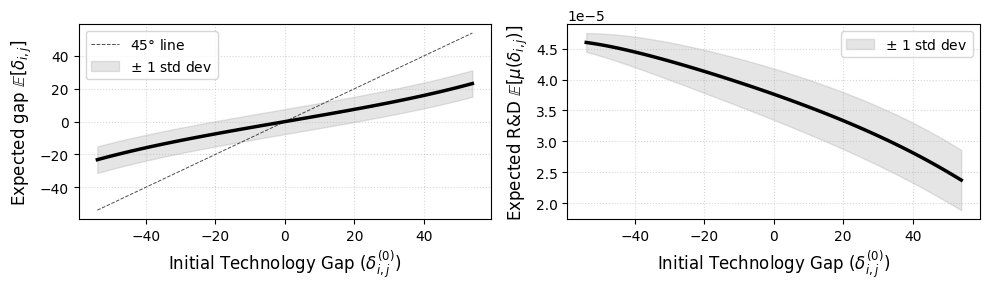

In [178]:
fig, axs = plt.subplots(
    figsize=(10, 3), ncols=2, nrows=1,
    gridspec_kw={'width_ratios': [1, 1]},
    sharex=True
)


ax = axs[0]
ax.plot(df['initial_gap'], df['initial_gap'], color='black', linestyle='--', alpha=0.7, linewidth=0.7, label=r"$45\degree$ line")
ax.grid(alpha=0.5, linestyle=':')
df['minus_std'] = df['expected_gap'] - df['std_gap']
df['plus_std'] = df['expected_gap'] + df['std_gap']
ax.fill_between(df['initial_gap'], df['minus_std'], df['plus_std'], color='tab:gray', alpha=0.2, label=r"$\pm$ 1 std dev")
sns.lineplot(data=df, x='initial_gap', y='expected_gap', color='black', ax=ax, linewidth=2.5)
ax.set_xlabel(r"Initial Technology Gap ($\delta_{i,j}^{(0)}$)")
ax.set_ylabel(r"Expected gap $\mathbb{E}[\delta_{i,j}]$")
ax.legend()


ax = axs[1]
ax.grid(alpha=0.5, linestyle=':')
sns.lineplot(data=df, x='initial_gap', y='exp_policy', color='black', ax=ax, linewidth=2.5)
ax.fill_between(df['initial_gap'], df['exp_policy'] - df['std_policy'], df['exp_policy'] + df['std_policy'], color='tab:gray', alpha=0.2, label=r"$\pm$ 1 std dev")
ax.set_xlabel(r"Initial Technology Gap ($\delta_{i,j}^{(0)}$)")
ax.set_ylabel(r"Expected R&D $\mathbb{E}[\mu(\delta_{i,j})]$")
ax.legend()

fig.tight_layout()

plt.savefig("../output/2-firm/python_plot/expected_gap_n2.pdf", bbox_inches='tight')

In [154]:
# find stationary distribution for the case where the initial gap is 0
eigenvalues, eigenvectors = np.linalg.eig(P.T)
stationary_dist = np.real(eigenvectors[:, np.isclose(eigenvalues, 1)].flatten())
stationary_dist /= stationary_dist.sum()  # Normalize to sum to 1

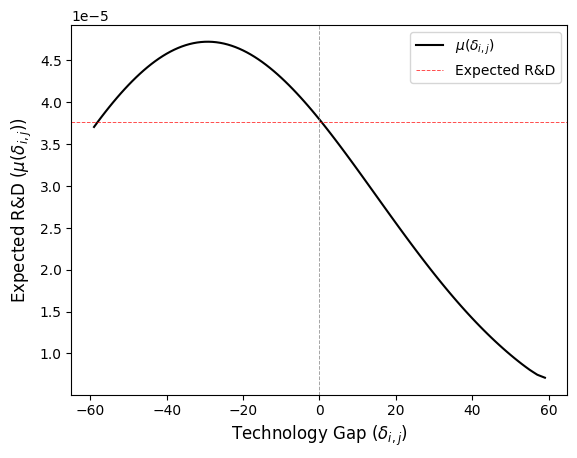

In [170]:
exp_l = np.sum(stationary_dist * policy_func)

plt.plot(d_states, policy_func, color='black', label=r"$\mu(\delta_{i,j})$")
plt.axhline(exp_l, color='red', linestyle='--', alpha=0.7, linewidth=0.7, label=r"Expected R&D")
plt.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
plt.xlabel(r"Technology Gap ($\delta_{i, j}$)")
plt.ylabel(r"Expected R&D ($\mu(\delta_{i,j})$)")
plt.legend()
plt.show()


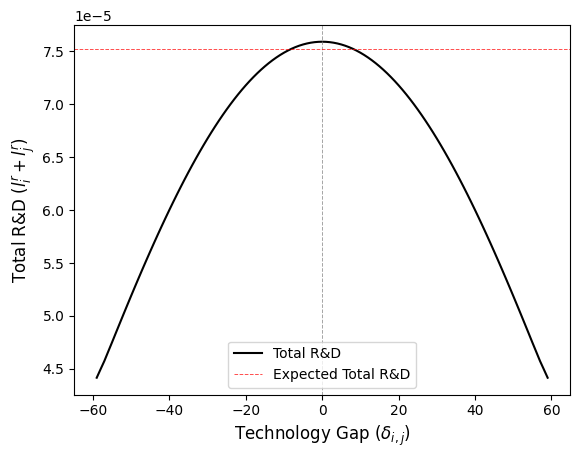

In [168]:
exp_total = np.sum(stationary_dist * total_demand[1:-1])

plt.plot(d_states, total_demand[1:-1], color='black', label="Total R&D")
plt.axvline(0, color='tab:gray', linestyle='--', alpha=0.7, linewidth=0.7)
plt.axhline(exp_total, color='red', linestyle='--', alpha=0.7, linewidth=0.7, label=r"Expected Total R&D")
plt.xlabel(r"Technology Gap ($\delta_{i, j}$)")
plt.ylabel(r"Total R&D ($l^r_i + l^r_j$)")
plt.legend()
plt.show()